# Vertical integration

**Vertical integration** fuses several modalities measured **in the same cells** (here CITE-seq: RNA + surface protein). Cells are already matched, so the task is combining modalities, not aligning cells.

This tutorial covers, end to end:

- installing the package and the per-method environments
- the on-disk data layout this category expects
- seeing what runs on a dataset (`scan`) and what each method exposes for tuning
- running several methods for real and reading their metrics
- the standard figures: a per-dataset panel and an across-datasets summary
- **running the same pipeline on your own dataset**, demonstrated for real

**Reference dataset:** `D11` (2,864 cells). The stored results shipped
with these notebooks were produced on it, so every table below reproduces.

**Contents** - 1 Install · 2 Data layout · 3 What can I run · 4 Paper coverage ·
5 What can I tune · 6 Run the analysis · 7 Reading the metrics · 8 Figures ·
9 Your own dataset · Troubleshooting

## 1. Install

Two layers: the `multibench` package (~2 MB) and the conda environments of the
methods you run. On **Colab**, run the first cell and let the kernel restart
once - then just keep running from the next cell.

In [1]:
# Colab ships without conda; this provisions it (the kernel restarts ONCE).
# On a machine that already has conda, this cell does nothing.
import importlib.util, shutil

def _has(mod):
    try:
        return importlib.util.find_spec(mod) is not None
    except ModuleNotFoundError:
        return False

if shutil.which("conda") or shutil.which("mamba"):
    print("conda available - nothing to do")
elif _has("google.colab"):
    !pip -q install condacolab
    import condacolab
    condacolab.install()   # restarts the kernel; afterwards, continue below
else:
    print("no conda found - install it first (mamba recommended); see the installation guide")

conda available - nothing to do


In [2]:
import importlib.util, os
if importlib.util.find_spec("multibench") is None:
    !git clone --depth 1 https://github.com/DSichang/scMultiBench.git
    %cd scMultiBench
    !pip -q install -e ".[eval]"
elif os.path.isdir("/content/scMultiBench"):
    # reused Colab runtime: refresh the editable install to the latest code,
    # then drop the already-imported modules so the NEXT import sees it -
    # a live kernel never re-reads changed files on its own
    %cd /content/scMultiBench
    !git pull -q
    !pip -q install -e ".[eval]"
    import importlib, sys
    for _m in [m for m in list(sys.modules) if m == "multibench" or m.startswith("multibench.")]:
        del sys.modules[_m]
    importlib.invalidate_caches()
    print("multibench refreshed to the latest repository state")
else:
    print("multibench already installed")

multibench already installed


Now the environments for the methods this tutorial runs
(Matilda, scMM, sciPENN). `env install` skips anything already present;
other tiers are one flag away (`--category vertical`: ~101 GB (18 envs); no flag:
the whole benchmark, 29 envs / 175 GB).

In [3]:
import sys
# --packed uses prebuilt archives where published (minutes instead of a
# 10-30 min build); envs without one fall back to the lockfile build.
!{sys.executable} -m multibench env install --methods Matilda,scMM,sciPENN --packed --run

env_sciPENN        [have          ] <- sciPENN
matilda            [have          ] <- Matilda
scmb_scmm2         [have          ] <- scMM


In [4]:
import warnings; warnings.filterwarnings("ignore")
%matplotlib inline
from pathlib import Path
import pandas as pd
pd.set_option("display.max_colwidth", None)   # never truncate a `reason`
pd.set_option("display.max_columns", None)    # never hide a metric column
pd.set_option("display.width", 200)
import multibench as mtb

DATASET  = "D11"
CATEGORY = "vertical"
RESULTS = Path("results") if Path("results").exists() else Path("notebooks/results")
mtb.data.fetch('D11')   # reference data (11 MB); no-op when present
print("multibench", mtb.__version__)

multibench 0.2.1


## 2. The data layout

A dataset is a **folder of flat files**; the folder name is the dataset name.
`describe_layout` prints the exact filenames for each category:

In [5]:
print(mtb.describe_layout(CATEGORY))

Put your files in  <data_path>/<DATASET_NAME>/ , e.g. ./data/MYDATA/
  (dataset = the folder NAME; data_path = the folder that CONTAINS it)

LAYOUT FOR VERTICAL:
  rna.h5 + adt.h5 (CITE-seq)  or  rna.h5 + atac.h5 (multiome)
  cty.csv        <- ONE label file; the cells are already matched

  (numbered files live in the SAME flat dir; there is no batch column)

Modality roles and the filenames they resolve to:
    rna              rna.h5      - gene expression
    adt              adt.h5      - surface protein (CITE-seq antibody-derived tags)
    atac             atac.h5     - chromatin accessibility
    atac_gas         atac.h5     - ATAC as GENE-ACTIVITY scores  <-- note: plain atac.h5
    atac_peak        peak.h5     - ATAC as PEAKS                 <-- note: peak.h5, NOT atac.h5
    rna1/rna2/...    rna1.h5, rna2.h5, ... - one file per BATCH (mosaic/cross)
    adt1/adt2/...    adt1.h5, adt2.h5, ... - one file per BATCH (mosaic/cross)
    cty              cty.csv     - cell-type label

The modality files are HDF5 with three required datasets:

| dataset | contents | shape |
|---|---|---|
| `matrix/data` | the matrix, **features x cells** | `(n_features, n_cells)` |
| `matrix/features` | one name per feature | `(n_features,)` |
| `matrix/barcodes` | one id per cell | `(n_cells,)` |

Note this is the **transpose** of the scanpy/AnnData convention (`AnnData.X` is
cells x genes). Two safety nets exist: `mtb.io.to_canonical(src, dst)` converts
an `.h5ad` correctly, and `scan()` rejects a transposed file at preflight instead
of letting a method fail half an hour in.

**The label CSV** is the one file you author by hand, so its schema in full:
a **single column** with one header line (typically `x`) and one label per
cell, in **the same order as `matrix/barcodes`** of the matching modality
file(s) - the evaluator reads the first column and skips the header line.
Where a category uses several label files (`cty1.csv`, `rna_cty.csv`, ...),
each aligns with its own batch or modality. The next cell prints the head of a
shipped one - this is the whole format:

In [6]:
cty = sorted((mtb.config.DEFAULT.data_path / DATASET).glob("*cty*.csv"))[0]
print(cty.name)
print(*open(cty).read().splitlines()[:4], sep="\n")

cty.csv
"x"
"mDC.Lung"
"T.CD.EM"
"B.Plasma.1"


> **ATAC caution.** Methods disagree about the ATAC representation - some need
> **gene-activity scores**, others need **peaks** - and feeding the wrong one
> runs to completion and returns a plausible but wrong embedding, with no error.
> `describe_layout` above states which file resolves where; check what your
> files actually contain before trusting a result.

**From AnnData to canonical, executed.** Most real data starts as `.h5ad`;
`mtb.io.to_canonical` writes the layout above correctly (including the
transpose). Converting a small demo object end to end:

In [7]:
import importlib.util
if importlib.util.find_spec("anndata"):
    import anndata as ad, numpy as np, h5py, tempfile, os
    tmp = tempfile.mkdtemp()
    demo = ad.AnnData(X=np.random.poisson(2.0, size=(120, 40)).astype(float))
    demo.obs_names = [f"cell{i}" for i in range(120)]
    demo.var_names = [f"gene{i}" for i in range(40)]
    src = os.path.join(tmp, "demo.h5ad"); demo.write_h5ad(src)

    dst = os.path.join(tmp, "rna.h5")
    mtb.io.to_canonical(src, dst)
    with h5py.File(dst) as f:
        print("keys :", sorted(f["matrix"].keys()))
        print("shape:", f["matrix/data"].shape, "(features x cells - transposed for you)")
else:
    print("skipped - anndata not installed here (an evaluation-only dependency;",
          "a full `pip install -e .` on your own machine brings it in)")

keys : ['barcodes', 'data', 'features']
shape: (40, 120) (features x cells - transposed for you)


## 3. What can I run on this dataset?

`scan` inspects the folder and reports every method that can run - and, for the
rest, exactly why not (missing file, missing environment, wrong layout). Nothing
executes, so this is instant and safe.

In [8]:
avail = mtb.scan(DATASET, category=CATEGORY)
avail[avail.runnable][["method", "modalities", "env", "output_kind",
                       "n_tunable", "runtime_tier"]]

,method,modalities,env,output_kind,n_tunable,runtime_tier
0,Concerto,rna+adt,scmb_concerto,embedding,0,very_slow
1,MOFA2,rna+adt,MOFA2_env,embedding,0,medium
2,Matilda,rna+adt,matilda,embedding,10,fast
3,Multigrate,rna+adt,scmb_multigrate2,embedding,3,very_slow
4,Seurat_WNN,rna+adt,scmb_seurat5,graph,0,medium
5,UINMF,rna+adt,scmb_r,embedding,0,fast
6,VIMCCA,rna+adt,scmb_vimcca,embedding,0,medium
7,moETM,rna+adt,env_moETM,embedding,0,medium
8,scMDC,rna+adt,scmb_scmdc,embedding,24,slow
9,scMM,rna+adt,scmb_scmm2,embedding,19,medium


Methods that are *not* runnable come with a reason rather than a silent absence:

In [9]:
not_ok = avail[~avail.runnable][["method", "modalities", "reason"]]
not_ok.head(5) if len(not_ok) else "(everything in this category runs here)"


,method,modalities,reason
14,MIRA,rna+atac,"FileNotFoundError: MIRA/D11/vertical: input files not found on disk: {'atac': '/media/disk2/Sichang/scmbench_pkg/data/D11/atac.h5'}. Available files in /media/disk2/Sichang/scmbench_pkg/data/D11: ['adt.h5', 'cty.csv', 'rna.h5', 'scMM_data']"
15,Matilda,rna+atac,"FileNotFoundError: Matilda/D11/vertical: input files not found on disk: {'atac': '/media/disk2/Sichang/scmbench_pkg/data/D11/atac.h5'}. Available files in /media/disk2/Sichang/scmbench_pkg/data/D11: ['adt.h5', 'cty.csv', 'rna.h5', 'scMM_data']"
16,Seurat_WNN,rna+atac,"FileNotFoundError: Seurat_WNN/D11/vertical: input files not found on disk: {'atac': '/media/disk2/Sichang/scmbench_pkg/data/D11/atac.h5'}. Available files in /media/disk2/Sichang/scmbench_pkg/data/D11: ['adt.h5', 'cty.csv', 'rna.h5', 'scMM_data']"
17,UnitedNet,rna+atac_gas,"FileNotFoundError: UnitedNet/D11/vertical: input files not found on disk: {'atac_gas': '/media/disk2/Sichang/scmbench_pkg/data/D11/atac_gas.h5', 'rna_cty': '/media/disk2/Sichang/scmbench_pkg/data/D11/rna_cty.csv'}. Available files in /media/disk2/Sichang/scmbench_pkg/data/D11: ['adt.h5', 'cty.csv', 'rna.h5', 'scMM_data']"
18,VIMCCA,rna+atac,"FileNotFoundError: VIMCCA/D11/vertical: input files not found on disk: {'atac': '/media/disk2/Sichang/scmbench_pkg/data/D11/atac.h5'}. Available files in /media/disk2/Sichang/scmbench_pkg/data/D11: ['adt.h5', 'cty.csv', 'rna.h5', 'scMM_data']"


## 4. How much of the paper does this cover?

`scan()` answers "what runs on THIS dataset". A different question: how many of
the methods the paper benchmarks for **vertical** does this package wire at all?
Stated explicitly so you never mistake a dataset limitation for full coverage.

In [10]:
from multibench.engine import registry

PAPER = {'vertical': ['totalVI', 'sciPENN', 'Concerto', 'scMSI', 'Matilda', 'MOFA2', 'Multigrate', 'UINMF', 'scMoMaT', 'Seurat_WNN', 'scMM', 'scMDC', 'moETM', 'VIMCCA', 'iPOLNG', 'MIRA', 'UnitedNet', 'scMVP'], 'diagonal': ['scBridge', 'Portal', 'SCALEX', 'VIPCCA', 'Seurat_v3', 'MultiMAP', 'Seurat_v5', 'sciCAN', 'Conos', 'iNMF', 'online_iNMF', 'scJoint', 'GLUE', 'uniPort'], 'mosaic': ['MultiVI', 'scMoMaT', 'StabMap', 'Cobolt', 'UINMF', 'Multigrate', 'SMILE', 'scMM', 'moETM', 'UnitedNet', 'totalVI', 'sciPENN'], 'cross': ['totalVI', 'scMoMaT', 'UnitedNet', 'sciPENN', 'Concerto', 'scMDC', 'StabMap', 'UINMF', 'scMM', 'MOFA2', 'Multigrate', 'PASTE', 'PASTE2', 'SPIRAL', 'GPSA']}
IMPUTATION_ONLY = ['scMM', 'moETM', 'UnitedNet', 'totalVI', 'sciPENN']

paper = PAPER[CATEGORY]
wired = sorted({m for m in mtb.list_methods()
                if any(v.when.get("category") == CATEGORY
                       for v in registry.get(m).variants)})
missing = [m for m in paper if m not in wired]
print(f"paper benchmarks {len(paper)} methods for {CATEGORY}; this package wires {len(wired)}")
if missing:
    print("not wired here:", ", ".join(missing))
    imp = [m for m in missing if m in IMPUTATION_ONLY]
    if imp:
        print("  the paper evaluates these only via IMPUTATION, which is not wired:",
              ", ".join(imp))
else:
    print("full parity with the paper for this category")

paper benchmarks 18 methods for vertical; this package wires 18
full parity with the paper for this category


## 5. What can I tune?

`params_for` reports each method's defaults and, where the upstream script
exposes any, the tunable hyperparameters. **An empty `tunable` is honest**: many
upstream scripts hardcode their hyperparameters, and this package never edits
upstream code, so it reports rather than pretends.

In [11]:
# a registry question, so it needs no data on disk
from multibench.engine import registry

rows = []
for m in sorted(mtb.list_methods(category=CATEGORY)):
    p = None
    try:
        p = mtb.params_for(m, CATEGORY)
    except Exception:                      # multi-variant: try each variant's modalities
        for v in registry.get(m).variants:
            if v.when.get("category") != CATEGORY:
                continue
            try:
                p = mtb.params_for(m, CATEGORY, v.when.get("modalities"))
                break
            except Exception:
                continue
    if p is None:                          # variant selection needs a concrete dataset
        rows.append({"method": m, "n_tunable": 0, "tunable": "(see scan() on your dataset)"})
        continue
    rows.append({"method": m, "n_tunable": len(p.get("tunable") or {}),
                 "tunable": ", ".join(sorted((p.get("tunable") or {}))[:6])})
pd.DataFrame(rows).sort_values("n_tunable", ascending=False).reset_index(drop=True)

,method,n_tunable,tunable
0,scMDC,24,"batch_size, cutoff, data_file, device, f1, f2"
1,scMM,19,"analytics, batch_size, deterministic_warmup, epochs, experiment, latent_dim"
2,Matilda,10,"augmentation, batch_size, device, epochs, hidden_adt, hidden_atac"
3,MIRA,8,"acc, atac_topic_modal_path, epoch, filter_atac_cells, latent_dim, load_model"
4,Multigrate,3,"bs, epochs, lr"
5,sciPENN,1,seed
6,UnitedNet,1,index
7,Concerto,0,
8,scMoMaT,0,
9,scMVP,0,


## 6. Run the analysis

`run_all` is the whole pipeline in one call: resolve inputs -> run each method
in its own conda env -> load the outputs -> compute scIB metrics. Here:
Matilda, sciPENN, scMM on `D11`. Matilda at 5 epochs is quick - `run_sec` below is the measured time on our host.

In [12]:
res = mtb.run_all("D11", CATEGORY,
                  methods=['Matilda', 'sciPENN', 'scMM'], params={"Matilda": {"epochs": 5}},
                  out_dir="/tmp/tutorial_vertical")
res.summary

[run_all] Matilda (vertical/D11) ...


/media/disk2/Sichang/.conda/envs/scmbench_eval/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[run_all]   -> CHAIN_OK (8.8s) 0.8731


[run_all] scMM (vertical/D11) ...


[run_all]   -> CHAIN_OK (36.2s) 0.6939


[run_all] sciPENN (vertical/D11) ...


[run_all]   -> CHAIN_OK (10.0s) 0.6416


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,ARI,NMI,ASW,iASW,iF1,cLISI,label_order_note
0,Matilda,CHAIN_OK,8.8,embedding,"[2864, 100]",10,cty.csv,None,0.8731,0.8698,0.5978,0.5817,0.8179,0.9961,single ordering
1,scMM,CHAIN_OK,36.2,embedding,"[2864, 10]",19,cty.csv,None,0.6939,0.7228,0.5722,0.5479,0.6382,0.9720,single ordering
2,sciPENN,CHAIN_OK,10.0,embedding,"[2864, 512]",1,cty.csv,None,0.6416,0.6966,0.6313,0.6248,0.6558,0.9799,single ordering


`run_all` picked the right label files, resolved the label order (see
`label_order` in the summary), and scored every embedding. Your first figure -
the methods you just ran, in the paper's panel layout:

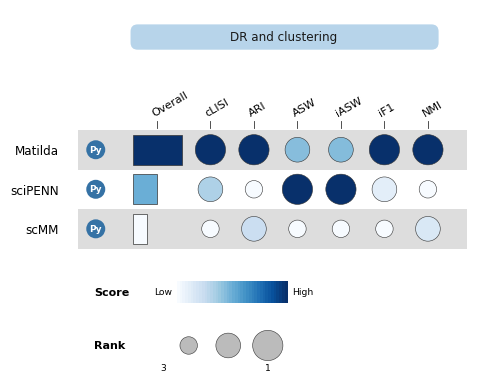

In [13]:
res.plot()

## 7. Reading the metrics

Two families, matching the paper's grouping. All are **higher = better**, on
[0, 1] except ARI (can be slightly negative at chance level).

| family | metrics | what they measure |
|---|---|---|
| clustering / bio-conservation | `ARI`, `NMI`, `ASW`, `iASW`, `iF1`, `cLISI` | does the embedding separate the annotated cell types? |
| batch correction | `ASW_batch`, `GC`, `iLISI` (+ opt-in `kBET`) | are the batches mixed within each cell type? |

Notes that save confusion later:

- `iASW`/`iF1` are **isolated-label** scores; this benchmark scores *every*
  label, so they exist even on a single-batch dataset.
- batch metrics appear only when the dataset has real batches - their absence on
  a single-batch dataset is correct, not missing data.
- `kBET` is opt-in (`mtb.evaluate(..., slow_metrics=True)`): it is much slower
  than the other metrics.

## 8. The figures

Section 6 plotted the methods you ran; the same call scales to the **whole
field**. The stored full-benchmark sweep for `D11` (every wired method,
default settings - hours of compute, shipped with the repository so this
reproduces instantly) gives the paper-style panel:

**Per-dataset panel**, in the paper's layout: methods as rows (best first),
metrics as columns grouped by task family - blues for DR & clustering, greens
for batch correction - each family led by an **Overall** rank column. Read each
circle as two encodings: its **size is the method's rank** within that column
(largest = rank 1) and its **colour is the metric's value** (min-max scaled
within the column, darker = higher); the Overall columns use bar length and
colour the same way. This is the full stored benchmark for `D11`; to produce the same files for your own
data, `mtb.run_all(DATASET, CATEGORY, out_dir=...)` without `methods=` runs
everything runnable and writes `summary.csv` and `long.csv` into `out_dir`.

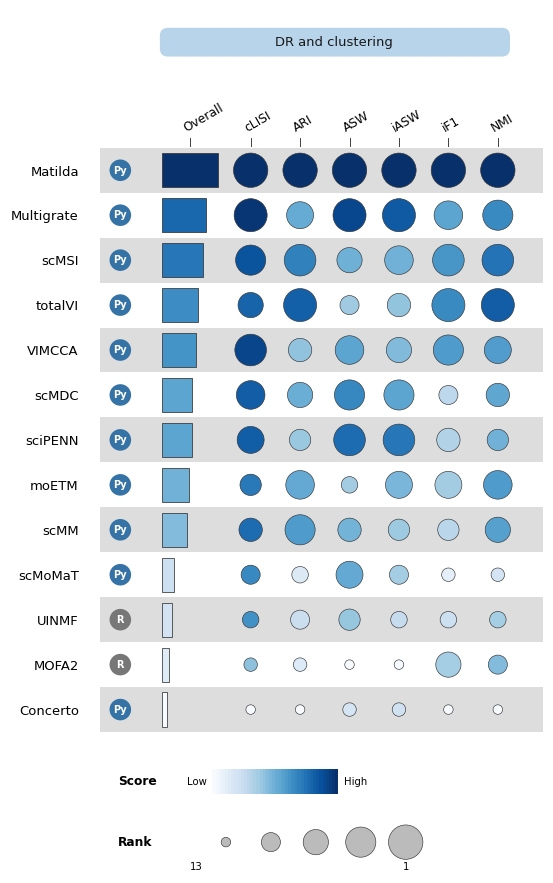

In [14]:
long = pd.read_csv(RESULTS / "long_all_D11.csv")
fig = mtb.plot.bubble(long)
fig.set_dpi(110)
fig

**Across datasets.** The summary figure needs every method to have results on
every dataset it is averaged over - otherwise absence and performance get mixed
into the same bar. The results folder therefore ships TWO vertical datasets swept
with the same benchmark: `D11` and `D11s` (a 60% cell subsample of `D11`
under a new name). The code keeps the **intersection** of methods present in
both, so the matrix behind the figure is complete by construction - copy this
pattern with your own same-category datasets. The encoding is the paper's:
each metric's bar is its **grand rank** - the min-max scaled mean rank across
the datasets - with length and colour both carrying it, and `Overall` is the
min-max scaled mean rank of the grand ranks, exactly as in the paper's summary
panels. Both datasets are single-batch, so this category's summary shows the clustering family only - the diagonal, mosaic and cross tutorials show the batch-correction family alongside it.

13 methods with results on both datasets


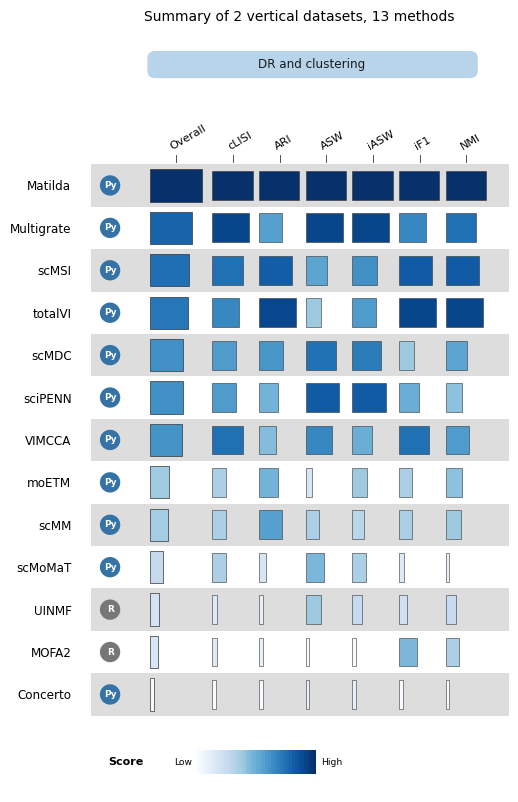

In [15]:
a = pd.read_csv(RESULTS / "long_all_D11.csv").assign(dataset="D11")
b = pd.read_csv(RESULTS / "long_all_D11s.csv").assign(dataset="D11s")
both = sorted(set(a.method) & set(b.method))   # complete matrix, by construction
pair = pd.concat([a, b], ignore_index=True)
pair = pair[pair.method.isin(both)]
print(f"{len(both)} methods with results on both datasets")
mtb.plot.bubble(pair, aggregate="summary",
                title=f"Summary of 2 vertical datasets, {len(both)} methods")

## 9. Your own dataset - for real

Everything above used shipped data. This section does what you will actually do:
put files in a folder, point the package at it, and get scored results - executed
here on a dataset the package has never seen (a 60% cell subsample of
`D11` under a new name, built with ordinary h5py/pandas code you can
adapt to your own export pipeline).

In [16]:
import os, shutil
import h5py
import numpy as np
import pandas as pd

def subsample_dataset(src_dir, dst_dir, frac=0.6, seed=0):
    """Copy a dataset to a new name, keeping a random fraction of the cells.

    Files sharing a cell count get the SAME kept-cell index, so modality files
    and their label CSVs stay aligned - which is exactly the property your own
    export pipeline must preserve. The output is the canonical layout:
    matrix/data as features x cells, plus matrix/features and matrix/barcodes.
    """
    rng = np.random.default_rng(seed)
    os.makedirs(dst_dir, exist_ok=True)
    counts, keep = {}, {}
    for fn in sorted(os.listdir(src_dir)):
        p = os.path.join(src_dir, fn)
        if fn.endswith(".h5"):
            with h5py.File(p) as f:
                if "matrix/data" in f:
                    counts[fn] = f["matrix/data"].shape[1]   # features x cells
        elif fn.endswith(".csv"):
            counts[fn] = len(pd.read_csv(p))
    for n in set(counts.values()):
        k = max(50, int(n * frac))
        keep[n] = np.sort(rng.choice(n, size=k, replace=False))
    for fn, n in counts.items():
        sp, dp = os.path.join(src_dir, fn), os.path.join(dst_dir, fn)
        idx = keep[n]
        if fn.endswith(".csv"):
            pd.read_csv(sp).iloc[idx].to_csv(dp, index=False)
        else:
            with h5py.File(sp) as f, h5py.File(dp, "w") as g:
                grp = g.create_group("matrix")
                grp.create_dataset("data", data=np.asarray(f["matrix/data"])[:, idx])
                if "matrix/features" in f:
                    grp.create_dataset("features", data=np.asarray(f["matrix/features"]))
                if "matrix/barcodes" in f:
                    grp.create_dataset("barcodes", data=np.asarray(f["matrix/barcodes"])[idx])
    return dst_dir

In [17]:
DATA_ROOT = "/tmp/mydata"
src = mtb.config.DEFAULT.data_path / "D11"
subsample_dataset(src, f"{DATA_ROOT}/MYDATA_vertical", frac=0.6)

sc = mtb.scan(f"MYDATA_vertical", category=CATEGORY, data_path=DATA_ROOT)
print(f"{int(sc.runnable.sum())} of {len(sc)} methods can run on MYDATA_vertical")

14 of 25 methods can run on MYDATA_vertical


In [18]:
mine = mtb.run_all(f"MYDATA_vertical", CATEGORY,
                   methods=['Matilda', 'sciPENN', 'scMM'],
                   out_dir=f"{DATA_ROOT}/out_vertical",
                   data_path=DATA_ROOT)
mine.summary

[run_all] Matilda (vertical/MYDATA_vertical) ...


[run_all]   -> CHAIN_OK (10.3s) 0.9502


[run_all] scMM (vertical/MYDATA_vertical) ...


[run_all]   -> CHAIN_OK (24.3s) 0.5381


[run_all] sciPENN (vertical/MYDATA_vertical) ...


[run_all]   -> CHAIN_OK (8.3s) 0.6119


,method,status,run_sec,output_kind,emb_shape,n_tunable,label_order,label_order_confidence,ARI,NMI,ASW,iASW,iF1,cLISI,label_order_note
0,Matilda,CHAIN_OK,10.3,embedding,"[1718, 100]",10,cty.csv,None,0.9502,0.9480,0.6822,0.6916,0.9725,0.9994,single ordering
1,scMM,CHAIN_OK,24.3,embedding,"[1718, 10]",19,cty.csv,None,0.5381,0.6196,0.5365,0.5287,0.5944,0.9364,single ordering
2,sciPENN,CHAIN_OK,8.3,embedding,"[1718, 512]",1,cty.csv,None,0.6119,0.6882,0.6121,0.6092,0.6473,0.9686,single ordering


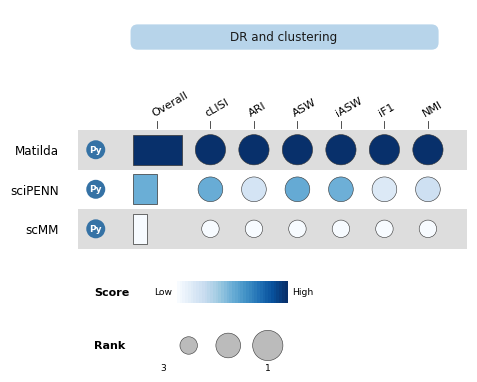

In [19]:
mine.plot()

When we ran this, Matilda scored ARI ~0.95 on the subsample - your exact numbers will differ slightly; the point is that they are high and computed end-to-end on data the package has never seen.

For your real data the only work is producing the canonical files: export each
modality with `mtb.io.to_canonical` (from `.h5ad`) or the h5py pattern above,
write one label CSV per the layout in section 2, and the same three calls -
`scan`, `run_all`, `plot` - do the rest.

## Troubleshooting

| symptom | meaning | fix |
|---|---|---|
| `scan` says not runnable: input files not found | a required file is absent | the reason names the exact file and lists what IS in the folder |
| `scan` says env missing | that method's conda env is not built | `multibench env install --run` |
| `... looks like cells x features` | matrix stored transposed | re-export with `mtb.io.to_canonical` |
| a method FAILs in seconds | wrong input representation or layout | read `res.failures.iloc[0]["error"]` - the full command line and stderr tail are there |
| a method TIMEOUTs | slow, not broken | raise `timeout=`; runtime tiers in `scan` are measured, not guessed |
| `label_order_confidence` low | several label files fit the cell count | check `label_order_candidates` in the record |


## Next steps

- the other three tutorials: **diagonal**, **mosaic**, **cross**
- the hosted interactive explorer: <https://shiny.maths.usyd.edu.au/scMultiBench/> -
  the full benchmark's rankings, browsable without installing anything
- `SETUP.md` - measured install cost and the smallest end-to-end check
- `mtb.method_info(name)` - everything the registry knows about one method
- `mtb.sweep(...)` - one method over a range of one hyperparameter